# Preparações de ambiente e leitura dos dados

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from urllib.request import urlretrieve
from zipfile import ZipFile

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
base_dir = Path('../database/')
input_file_path = base_dir.parent / "database"
output_dir = base_dir / "outputs"
output_dir.mkdir(exist_ok=True)

In [3]:
df_airlines = pd.read_csv(input_file_path / "airlines.csv")
df_airports = pd.read_csv(input_file_path / "airports.csv")

# Data Preprocessing

## Arrumando coordenadas faltantes na tabela de aeroportos
Identifiquei que 3 aeroportos ("ECP", "PBG", "UST") possuem o campo "LATITUDE" e "LONGITUDE" nulos. Para preencher esses valores, utilizei o Google Maps para obter as coordenadas geográficas de cada aeroporto.

In [4]:
IATA_CODEs_with_null_latitude = df_airports[df_airports["LATITUDE"].isnull()]["IATA_CODE"].tolist()
print(f"\nAeroportos com LATITUDE nula: {IATA_CODEs_with_null_latitude}")


Aeroportos com LATITUDE nula: ['ECP', 'PBG', 'UST']


In [5]:
coord_map = {
    "ECP": {"LATITUDE": 30.35483, "LONGITUDE": -85.79952},
    "PBG": {"LATITUDE": 44.65753, "LONGITUDE": -73.46695},
    "UST": {"LATITUDE": 29.95438, "LONGITUDE": -81.34289},
}

In [6]:
for iata_code, coords in coord_map.items():
    df_airports.loc[df_airports["IATA_CODE"] == iata_code, "LATITUDE"] = coords["LATITUDE"]
    df_airports.loc[df_airports["IATA_CODE"] == iata_code, "LONGITUDE"] = coords["LONGITUDE"]

# Conferindo se as coordenadas foram preenchidas corretamente
IATA_CODEs_with_null_latitude = df_airports[df_airports["LATITUDE"].isnull()]["IATA_CODE"].tolist()
print(f"\nAeroportos com LATITUDE nula: {IATA_CODEs_with_null_latitude}")



Aeroportos com LATITUDE nula: []


## Aeroportos de ORIGEM e DESTINO inconsistentes entre os datasets de voos e aeroportos

* O que foi identificado: alguns voos estão com códigos de aeroportos que não existem no dataset de aeroportos, o que pode indicar erros de digitação. Para facilitar a análise, os voos com códigos de aeroportos nulos foram exportados para um arquivo Excel, permitindo uma revisão detalhada dos casos problemáticos.
* Todos os casos dessa inconsistencia apresentam os dois lados em formato numérico, e o mais interessante, todos estão presentes em OUTUBRO de 2015.

In [7]:
## Solucionando o problema de aeroportos com nome nulo em apenas um dos lados (origem ou destino).
## Descobri que existe um arquivo do BTS (Bureau of Transportation Statistics) que contém o mapeamento entre AIRPORT_ID (numérico) e IATA_CODE (código de 3 letras). Utilizei esse arquivo para criar um mapeamento e substituir os AIRPORT_IDs pelos IATA_CODEs correspondentes, o que me permitiu preencher os nomes dos aeroportos corretamente.

## Código para baixar o arquivo ZIP do BTS (caso ainda não tenha sido baixado):
"""

bts_october_2015_url = (
    "https://transtats.bts.gov/PREZIP/"
    "On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2015_10.zip"
)
bts_zip_path = input_file_path / "external_bts_2015_10.zip"
airport_id_mapping_path = input_file_path / "airport_id_to_iata_2015_10.csv"

if not bts_zip_path.exists():
    urlretrieve(bts_october_2015_url, bts_zip_path)

with ZipFile(bts_zip_path) as bts_zip:
    bts_csv_name = [name for name in bts_zip.namelist() if name.endswith(".csv")][0]
    with bts_zip.open(bts_csv_name) as bts_csv:
        df_bts_airports = pd.read_csv(
            bts_csv,
            usecols=["OriginAirportID", "Origin", "DestAirportID", "Dest"],
            dtype={
                "OriginAirportID": "string",
                "Origin": "string",
                "DestAirportID": "string",
                "Dest": "string",
            },
        )

origin_airport_id_mapping = df_bts_airports[["OriginAirportID", "Origin"]].rename(
    columns={"OriginAirportID": "AIRPORT_ID", "Origin": "IATA_CODE"}
)
destination_airport_id_mapping = df_bts_airports[["DestAirportID", "Dest"]].rename(
    columns={"DestAirportID": "AIRPORT_ID", "Dest": "IATA_CODE"}
)
airport_id_mapping = (
    pd.concat([origin_airport_id_mapping, destination_airport_id_mapping])
    .drop_duplicates()
    .sort_values("AIRPORT_ID")
    .reset_index(drop=True)
)
airport_id_mapping.to_csv(airport_id_mapping_path, index=False)

"""

airport_id_mapping_path = input_file_path / "airport_id_to_iata_2015_10.csv"

if airport_id_mapping_path.exists():
    airport_id_mapping = pd.read_csv(airport_id_mapping_path, dtype={"AIRPORT_ID": "string", "IATA_CODE": "string"})
else:
    raise FileNotFoundError("Airport ID to IATA code mapping file not found.")

airport_id_to_iata = dict(
    zip(airport_id_mapping["AIRPORT_ID"], airport_id_mapping["IATA_CODE"])
)

df_flights = pd.read_csv(
    input_file_path / "flights.csv",
    dtype={
        "AIRLINE": "string",
        "ORIGIN_AIRPORT": "string",
        "DESTINATION_AIRPORT": "string",
    },
    low_memory=False,
)

mask_airport_inconsistency = (
    df_flights["ORIGIN_AIRPORT"].astype(str).str.len() > 3
) | (
    df_flights["DESTINATION_AIRPORT"].astype(str).str.len() > 3
)

# Mostrando aqui os voos que possuem códigos de aeroportos com mais de 3 caracteres, indicando que são códigos numéricos (AIRPORT_ID) ao invés de códigos IATA, o que é uma inconsistência em relação ao dataset de aeroportos. Esses casos foram exportados para um arquivo CSV para análise posterior.
output_path = output_dir / "flights_with_invalid_airport_codes.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df_flights.loc[mask_airport_inconsistency].to_csv(output_path, index=False)
print(f"Flights with invalid airport codes exported to: {output_dir / 'flights_with_invalid_airport_codes.csv'}")



Flights with invalid airport codes exported to: ..\database\outputs\flights_with_invalid_airport_codes.csv


In [8]:
# Colunas originais para comparação futura
df_flights["ORIGIN_AIRPORT_ORIGINAL"] = df_flights["ORIGIN_AIRPORT"]
df_flights["DESTINATION_AIRPORT_ORIGINAL"] = df_flights["DESTINATION_AIRPORT"]

df_flights.loc[mask_airport_inconsistency, "ORIGIN_AIRPORT"] = (
    df_flights.loc[mask_airport_inconsistency, "ORIGIN_AIRPORT"]
    .replace(airport_id_to_iata)
)

df_flights.loc[mask_airport_inconsistency, "DESTINATION_AIRPORT"] = (
    df_flights.loc[mask_airport_inconsistency, "DESTINATION_AIRPORT"]
    .replace(airport_id_to_iata)
)

# Flag para indicar quais linhas tiveram os códigos de aeroporto corrigidos
df_flights["AIRPORT_CODE_WAS_FIXED"] = mask_airport_inconsistency

In [9]:
# Validação dos ajustados
df_flights.loc[
    df_flights["AIRPORT_CODE_WAS_FIXED"],
    ["ORIGIN_AIRPORT_ORIGINAL", "ORIGIN_AIRPORT",
     "DESTINATION_AIRPORT_ORIGINAL", "DESTINATION_AIRPORT"]
].head()


,ORIGIN_AIRPORT_ORIGINAL,ORIGIN_AIRPORT,DESTINATION_AIRPORT_ORIGINAL,DESTINATION_AIRPORT
4385712,14747,SEA,11298,DFW
4385713,14771,SFO,13487,MSP
4385714,12889,LAS,13487,MSP
4385715,12892,LAX,13303,MIA
4385716,14771,SFO,11057,CLT


In [10]:
# Analisando se sobrou alguma inconsistência após a correção. Idealmente, não deveria haver mais nenhum código de aeroporto com mais de 3 caracteres, o que indicaria que todos os códigos numéricos foram convertidos para os códigos IATA correspondentes.
remaining_invalid = df_flights[
    (df_flights["ORIGIN_AIRPORT"].astype(str).str.len() > 3)
    | (df_flights["DESTINATION_AIRPORT"].astype(str).str.len() > 3)
]

remaining_invalid.shape

(0, 34)

In [11]:
df_flights.drop(columns=["ORIGIN_AIRPORT_ORIGINAL", "DESTINATION_AIRPORT_ORIGINAL", "AIRPORT_CODE_WAS_FIXED"], inplace=True)

## Arrumando nomes das colunas

In [12]:
airlines_lookup = df_airlines.rename(
    columns={
        "IATA_CODE": "AIRLINE",
        "AIRLINE": "AIRLINE_NAME",
    }
)

origin_airports_lookup = df_airports.rename(
    columns={
        "IATA_CODE": "ORIGIN_AIRPORT",
        "AIRPORT": "ORIGIN_AIRPORT_NAME",
        "CITY": "ORIGIN_CITY",
        "STATE": "ORIGIN_STATE",
        "COUNTRY": "ORIGIN_COUNTRY",
        "LATITUDE": "ORIGIN_LATITUDE",
        "LONGITUDE": "ORIGIN_LONGITUDE",
    }
)

destination_airports_lookup = df_airports.rename(
    columns={
        "IATA_CODE": "DESTINATION_AIRPORT",
        "AIRPORT": "DESTINATION_AIRPORT_NAME",
        "CITY": "DESTINATION_CITY",
        "STATE": "DESTINATION_STATE",
        "COUNTRY": "DESTINATION_COUNTRY",
        "LATITUDE": "DESTINATION_LATITUDE",
        "LONGITUDE": "DESTINATION_LONGITUDE",
    }
)

## JOIN entre as tabelas

In [13]:
df_join = (
    df_flights.merge(airlines_lookup, on="AIRLINE", how="left", validate="many_to_one")
    .merge(origin_airports_lookup, on="ORIGIN_AIRPORT", how="left", validate="many_to_one")
    .merge(destination_airports_lookup, on="DESTINATION_AIRPORT", how="left", validate="many_to_one")
)

In [14]:
df_resultado = df_join[
    (df_join["ORIGIN_AIRPORT"].astype(str).str.len() > 3) |
    (df_join["DESTINATION_AIRPORT"].astype(str).str.len() > 3)
]

df_resultado.to_csv(output_dir / "flights_with_invalid_airport_codes.csv", index=False)
print(f"Flights with invalid airport codes exported to: {output_dir / 'flights_with_invalid_airport_codes.csv'}")

Flights with invalid airport codes exported to: ..\database\outputs\flights_with_invalid_airport_codes.csv


## Ajustando tipos e criando colunas adicionais

In [15]:
df_join["FLIGHT_DATE"] = pd.to_datetime(df_join[["YEAR", "MONTH", "DAY"]])
df_join["SCHEDULED_DEPARTURE_HOUR"] = df_join["SCHEDULED_DEPARTURE"] // 100
df_join["SCHEDULED_ARRIVAL_HOUR"] = df_join["SCHEDULED_ARRIVAL"] // 100
df_join["ROUTE"] = df_join["ORIGIN_AIRPORT"] + "-" + df_join["DESTINATION_AIRPORT"]
df_join["IS_WEEKEND"] = df_join["DAY_OF_WEEK"].isin([6, 7])

## Separando os voos completos (sem valores nulos) para análises mais confiáveis dos atrasos

In [16]:
df_completed_raw = df_join[
    (df_join["CANCELLED"] == 0)
    & (df_join["DIVERTED"] == 0)
    & df_join["ARRIVAL_DELAY"].notna()
].copy()

df_completed = df_completed_raw.drop(
    columns=["CANCELLED", "DIVERTED", "CANCELLATION_REASON"]
).copy()

## Arrumando os nulos

In [17]:
delay_reason_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY",
]
df_completed[delay_reason_cols] = df_completed[delay_reason_cols].fillna(0)
df_completed["TAIL_NUMBER"] = df_completed["TAIL_NUMBER"].fillna("UNKNOWN")
df_completed["IS_DELAYED_15"] = df_completed["ARRIVAL_DELAY"] >= 15

## Analisando se as colunas nulas foram tratadas corretamente

In [18]:
# Dados antes do tratamento
column_profile = pd.DataFrame(
    {
        "column": df_completed_raw.columns,
        "dtype": df_completed_raw.dtypes.astype(str).values,
        "missing_count": df_completed_raw.isna().sum().values,
        "missing_pct": (df_completed_raw.isna().mean() * 100).round(2).values,
        "unique_count": df_completed_raw.nunique(dropna=True).values,
        "unique_pct": (
            df_completed_raw.nunique(dropna=True) / len(df_completed_raw) * 100
        ).round(4).values,
    }
).sort_values(["missing_pct", "unique_count"], ascending=[False, False])
column_profile.to_csv(output_dir / "completed_column_profile_before_treatment.csv", index=False)

column_profile

,column,dtype,missing_count,missing_pct,unique_count,unique_pct
25,CANCELLATION_REASON,str,5714008,100.00,0,0.0000
28,AIRLINE_DELAY,float64,4650569,81.39,1067,0.0187
29,LATE_AIRCRAFT_DELAY,float64,4650569,81.39,695,0.0122
30,WEATHER_DELAY,float64,4650569,81.39,632,0.0111
26,AIR_SYSTEM_DELAY,float64,4650569,81.39,570,0.0100
27,SECURITY_DELAY,float64,4650569,81.39,154,0.0027
5,FLIGHT_NUMBER,int64,0,0.00,6946,0.1216
6,TAIL_NUMBER,str,0,0.00,4896,0.0857
47,ROUTE,object,0,0.00,4657,0.0815
10,DEPARTURE_TIME,float64,0,0.00,1440,0.0252


In [19]:
# Dados depois do tratamento
clean_column_profile = pd.DataFrame(
    {
        "column": df_completed.columns,
        "dtype": df_completed.dtypes.astype(str).values,
        "missing_count": df_completed.isna().sum().values,
        "missing_pct": (df_completed.isna().mean() * 100).round(2).values,
        "unique_count": df_completed.nunique(dropna=True).values,
        "unique_pct": (df_completed.nunique(dropna=True) / len(df_completed) * 100)
        .round(4)
        .values,
    }
).sort_values(["missing_pct", "unique_count"], ascending=[False, False])
clean_column_profile.to_csv(output_dir / "completed_column_profile_after_treatment.csv", index=False)

clean_column_profile

,column,dtype,missing_count,missing_pct,unique_count,unique_pct
5,FLIGHT_NUMBER,int64,0,0.0,6946,0.1216
6,TAIL_NUMBER,str,0,0.0,4896,0.0857
44,ROUTE,object,0,0.0,4657,0.0815
10,DEPARTURE_TIME,float64,0,0.0,1440,0.0252
13,WHEELS_OFF,float64,0,0.0,1440,0.0252
18,WHEELS_ON,float64,0,0.0,1440,0.0252
21,ARRIVAL_TIME,float64,0,0.0,1440,0.0252
20,SCHEDULED_ARRIVAL,int64,0,0.0,1434,0.0251
17,DISTANCE,int64,0,0.0,1350,0.0236
9,SCHEDULED_DEPARTURE,int64,0,0.0,1320,0.0231


In [20]:
# Porcentagem de voos atrasados 15 minutos ou mais e porcentagem de voos no horário (menos de 15 minutos de atraso)
# O valor dos voos no horário justifica os nulos em métricas de atraso na base crua.
delay_percentage = (df_completed["IS_DELAYED_15"].mean() * 100).round(2)
print(f"Percentage of flights delayed by 15 minutes or more: {delay_percentage}%")
print(f"Percentage of flights on time: {100-delay_percentage}%")

Percentage of flights delayed by 15 minutes or more: 18.61%
Percentage of flights on time: 81.39%


In [21]:
# Analisando outliers
numeric_cols = df_completed.select_dtypes(include="number").columns
numeric_profile = df_completed[numeric_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T
numeric_profile["iqr"] = numeric_profile["75%"] - numeric_profile["25%"]
numeric_profile["lower_iqr_limit"] = numeric_profile["25%"] - 1.5 * numeric_profile["iqr"]
numeric_profile["upper_iqr_limit"] = numeric_profile["75%"] + 1.5 * numeric_profile["iqr"]
numeric_profile["outlier_count_iqr"] = [
    (
        (df_completed[col] < numeric_profile.loc[col, "lower_iqr_limit"])
        | (df_completed[col] > numeric_profile.loc[col, "upper_iqr_limit"])
    ).sum()
    for col in numeric_profile.index
]
numeric_profile["outlier_pct_iqr"] = (
    numeric_profile["outlier_count_iqr"] / len(df_completed) * 100
).round(2)
numeric_profile.to_csv(output_dir / "completed_numeric_profile.csv", index_label="column")

numeric_profile

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr,lower_iqr_limit,upper_iqr_limit,outlier_count_iqr,outlier_pct_iqr
YEAR,5714008.0,2015.000000,0.000000,2015.00000,2015.00000,2015.00000,2015.00000,2015.00000,2015.00000,2015.00000,2015.00000,2015.00000,0.00000,2015.000000,2015.000000,0,0.00
MONTH,5714008.0,6.547799,3.397421,1.00000,1.00000,1.00000,4.00000,7.00000,9.00000,12.00000,12.00000,12.00000,5.00000,-3.500000,16.500000,0,0.00
DAY,5714008.0,15.707591,8.774394,1.00000,1.00000,2.00000,8.00000,16.00000,23.00000,29.00000,31.00000,31.00000,15.00000,-14.500000,45.500000,0,0.00
DAY_OF_WEEK,5714008.0,3.932643,1.985967,1.00000,1.00000,1.00000,2.00000,4.00000,6.00000,7.00000,7.00000,7.00000,4.00000,-4.000000,12.000000,0,0.00
FLIGHT_NUMBER,5714008.0,2164.383547,1754.706022,1.00000,29.00000,166.00000,728.00000,1681.00000,3211.00000,5562.00000,6460.00000,9320.00000,2483.00000,-2996.500000,6935.500000,26659,0.47
SCHEDULED_DEPARTURE,5714008.0,1328.907421,483.525058,1.00000,530.00000,610.00000,916.00000,1325.00000,1730.00000,2115.00000,2245.00000,2359.00000,814.00000,-305.000000,2951.000000,0,0.00
DEPARTURE_TIME,5714008.0,1335.065627,496.419817,1.00000,511.00000,606.00000,921.00000,1330.00000,1740.00000,2132.00000,2300.00000,2400.00000,819.00000,-307.500000,2968.500000,0,0.00
DEPARTURE_DELAY,5714008.0,9.294842,36.889724,-82.00000,-13.00000,-9.00000,-5.00000,-2.00000,7.00000,67.00000,167.00000,1988.00000,12.00000,-23.000000,25.000000,730519,12.78
TAXI_OUT,5714008.0,16.065498,8.882449,1.00000,6.00000,8.00000,11.00000,14.00000,19.00000,31.00000,50.00000,225.00000,8.00000,-1.000000,31.000000,281167,4.92
WHEELS_OFF,5714008.0,1357.099048,498.023745,1.00000,510.00000,620.00000,935.00000,1343.00000,1754.00000,2143.00000,2307.00000,2400.00000,819.00000,-293.500000,2982.500000,0,0.00


* DEPARTURE_DELAY, TAXI_OUT, AIR_TIME, TAXI_IN, ARRIVAL_DELAY, AIR_SYSTEM_DELAY, SECURITY_DELAY, AIRLINE_DELAY, LATE_AIRCRAFT_DELAY, WEATHER_DELAY
* Essas colunas apresentaram outliers visuais via .describe(), vou observar mais de perto.

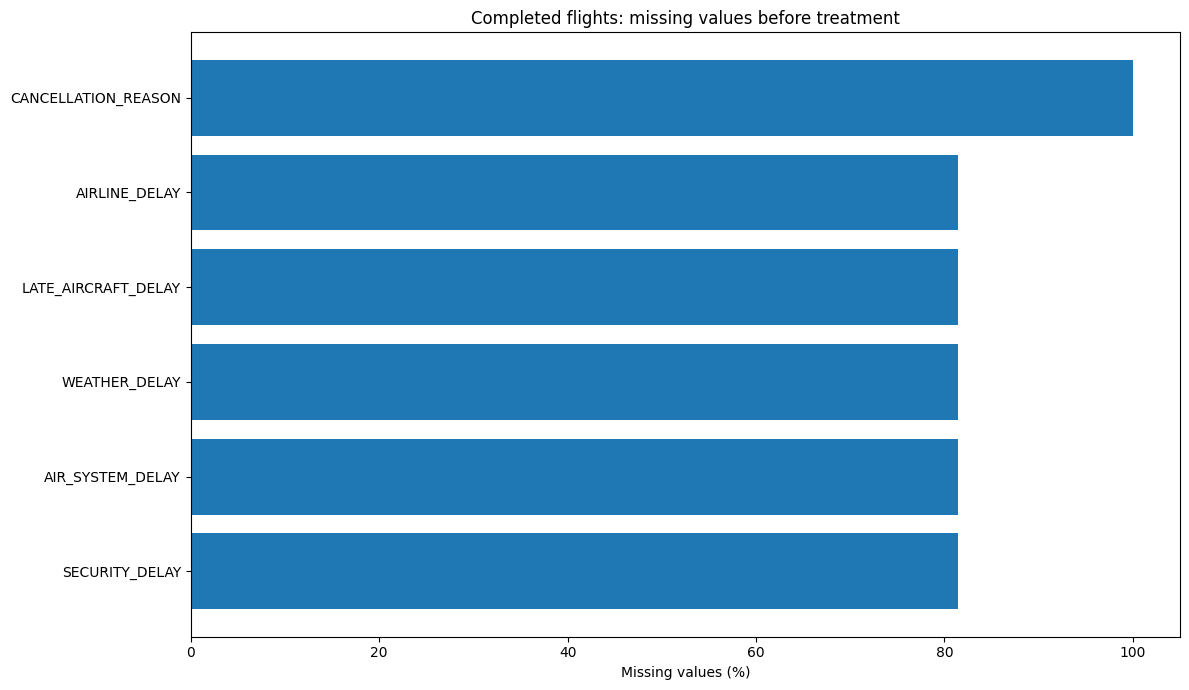

In [23]:
# Valores faltantes pré tratamento
missing_to_plot = column_profile[column_profile["missing_pct"] > 0].copy()
plt.figure(figsize=(12, 7))
plt.barh(missing_to_plot["column"], missing_to_plot["missing_pct"])
plt.xlabel("Missing values (%)")
plt.title("Completed flights: missing values before treatment")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(output_dir / "completed_missing_values.png", dpi=150)
plt.show()
plt.close()

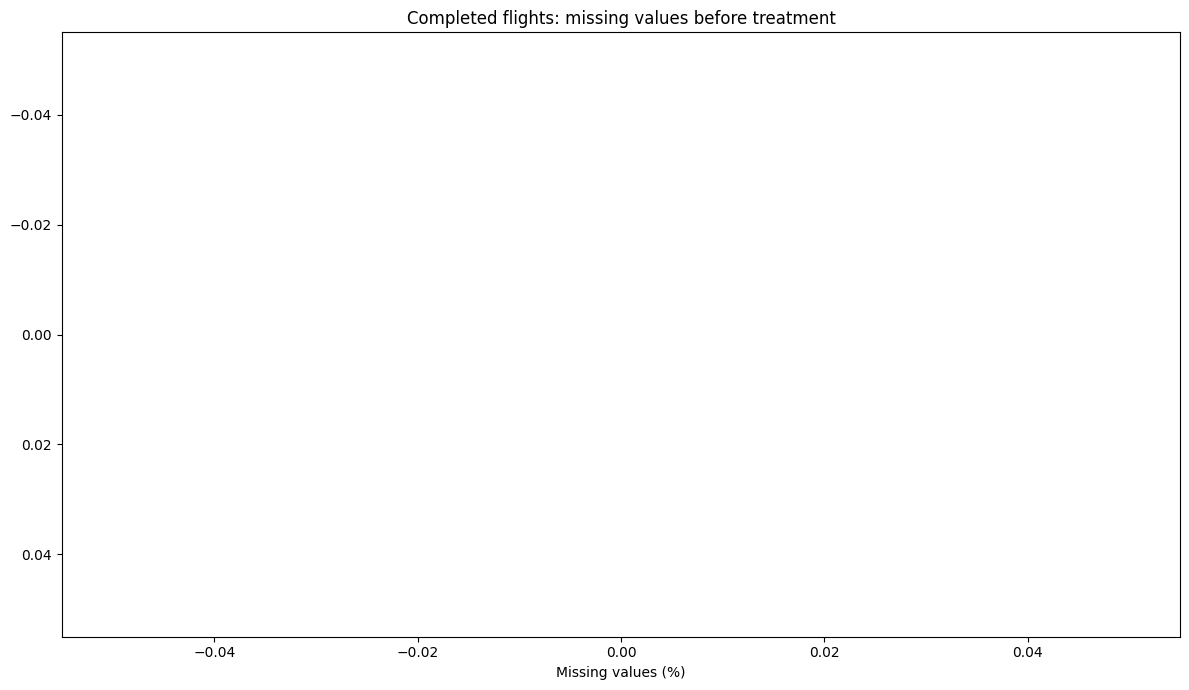

In [24]:
# Valores faltantes pós tratamento
missing_to_plot = clean_column_profile[clean_column_profile["missing_pct"] > 0].copy()
plt.figure(figsize=(12, 7))
plt.barh(missing_to_plot["column"], missing_to_plot["missing_pct"])
plt.xlabel("Missing values (%)")
plt.title("Completed flights: missing values before treatment")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(output_dir / "completed_missing_values.png", dpi=150)
plt.show()
plt.close()

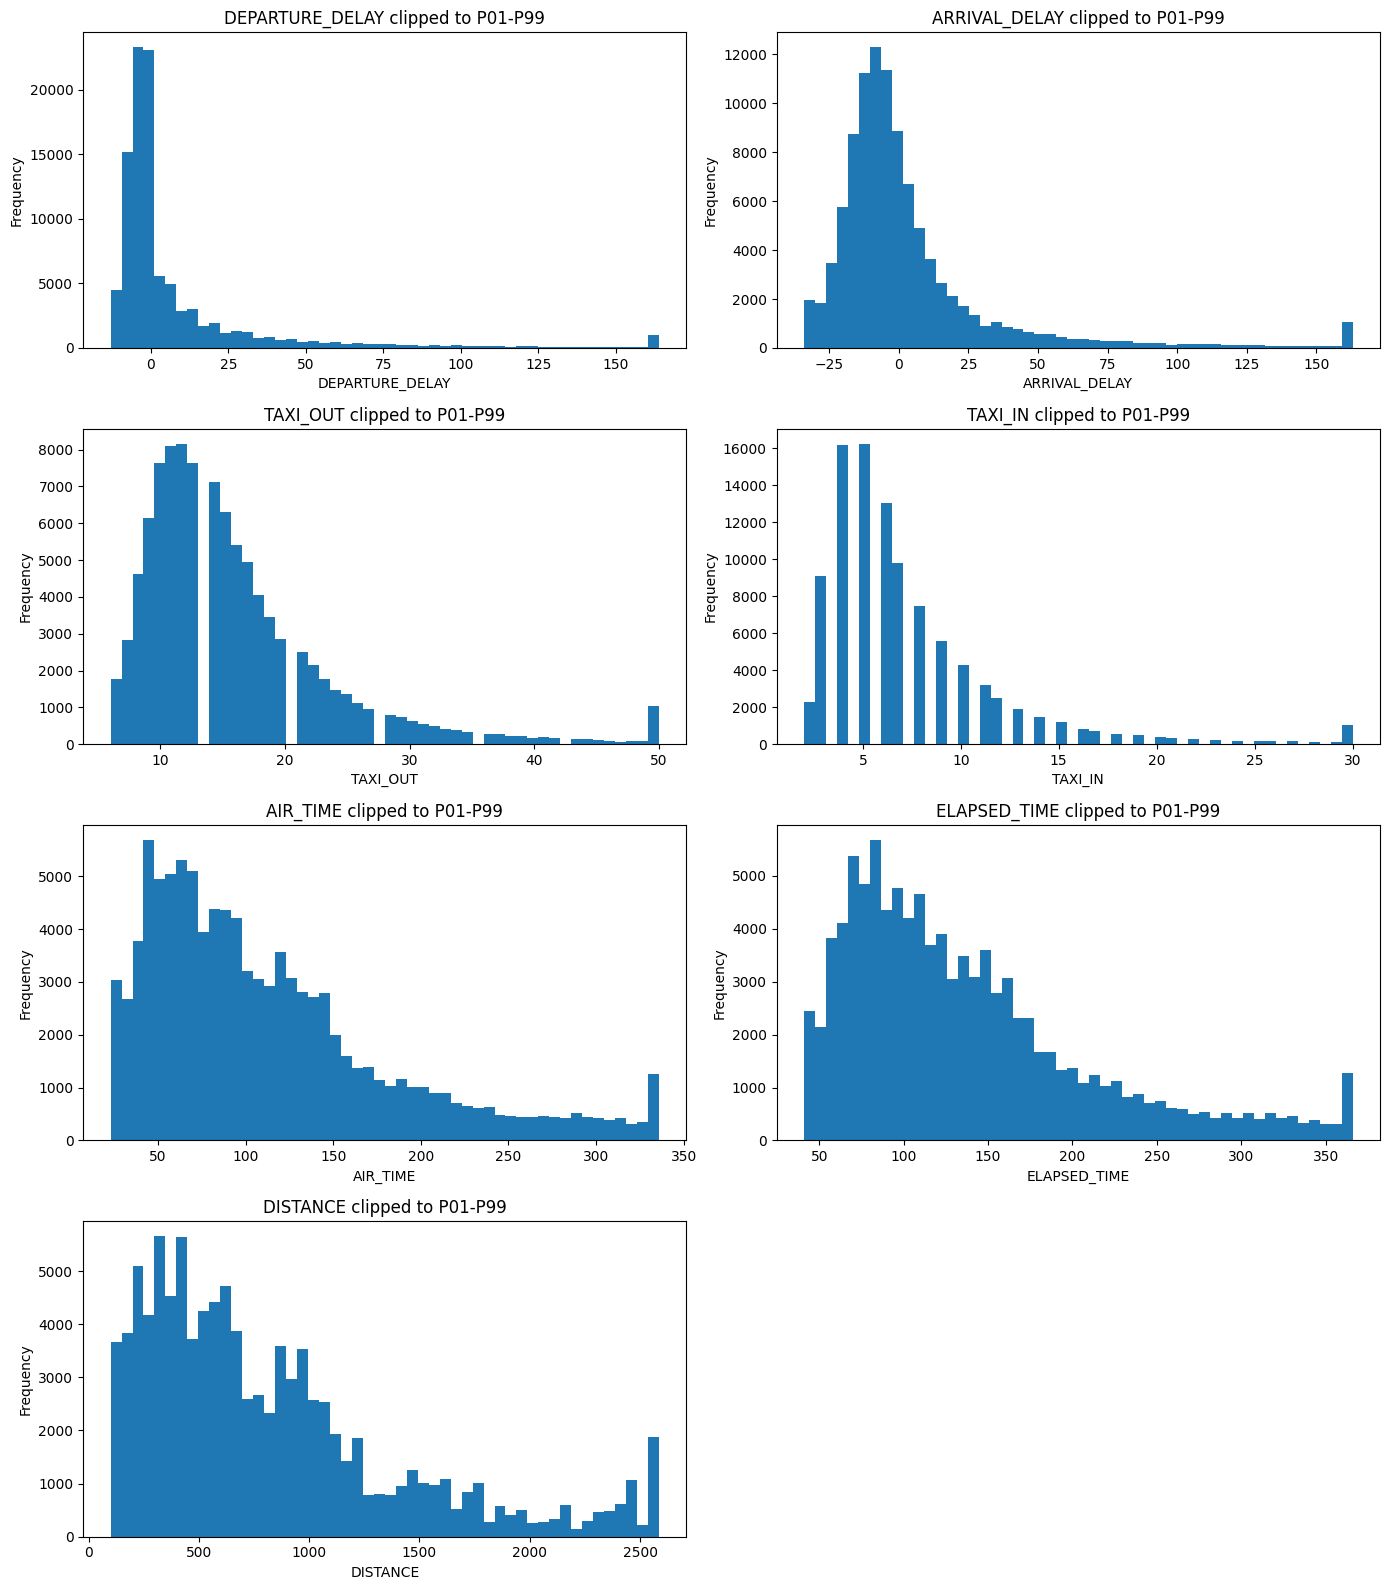

In [32]:
plot_numeric_cols = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "TAXI_OUT",
    "TAXI_IN",
    "AIR_TIME",
    "ELAPSED_TIME",
    "DISTANCE",
]
sample = df_completed.sample(n=min(100_000, len(df_completed)), random_state=42)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.ravel()
for idx, col in enumerate(plot_numeric_cols):
    values = sample[col].dropna()
    p01, p99 = values.quantile([0.01, 0.99])
    axes[idx].hist(values.clip(p01, p99), bins=50)
    axes[idx].set_title(f"{col} clipped to P01-P99")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frequency")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(output_dir / "completed_numeric_distributions.png", dpi=150)
plt.show()
plt.close()

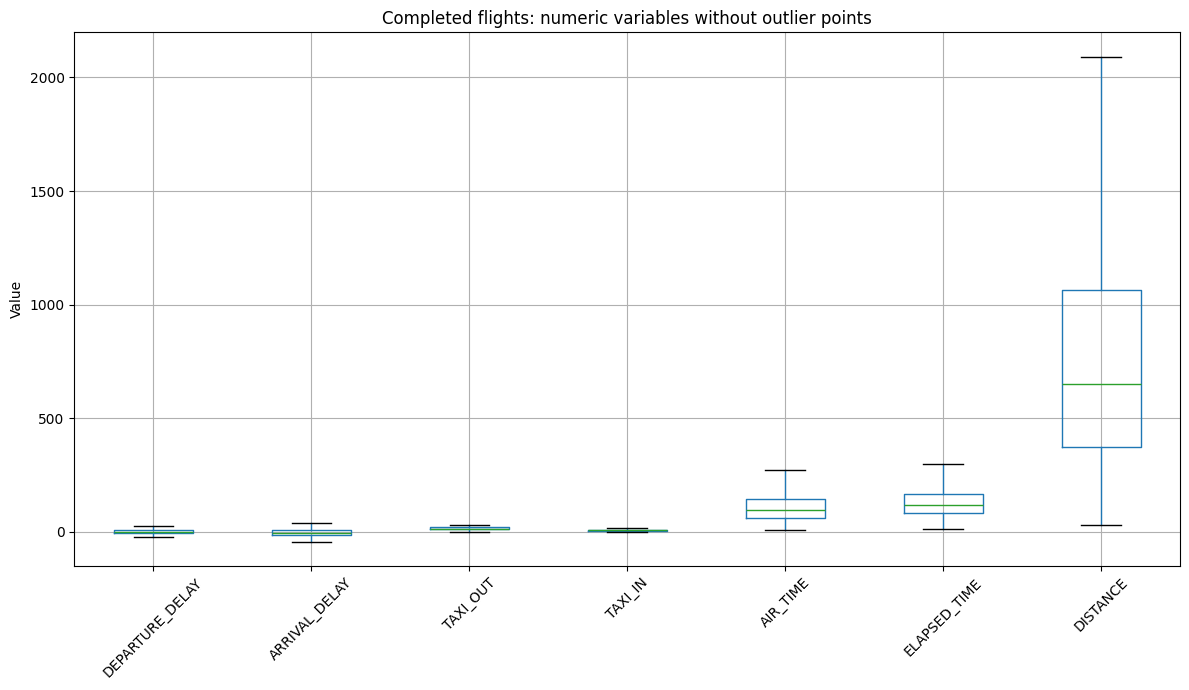

In [ ]:
# boxplot das colunas numéricas sem os outliers identificados pelo método do IQR, para visualizar melhor a distribuição dos dados centrais e comparar com as distribuições originais. Isso ajuda a entender o impacto dos outliers e a variabilidade dos dados sem eles.
df_completed.boxplot(column=plot_numeric_cols, rot=45, showfliers=False)
plt.title("Completed flights: numeric variables without outlier points")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig(output_dir / "completed_numeric_boxplots.png", dpi=150)
plt.show()
plt.close()

In [45]:
# Atraso por ROTA (origem + destino)
route_delay = (
    df_completed
    .dropna(subset=[
        "ORIGIN_LATITUDE", 
        "ORIGIN_LONGITUDE", 
        "DESTINATION_LATITUDE", 
        "DESTINATION_LONGITUDE"
    ])
    .groupby(
        [
            "ROUTE",
            "ORIGIN_AIRPORT",
            "ORIGIN_AIRPORT_NAME",
            "DESTINATION_AIRPORT",
            "DESTINATION_AIRPORT_NAME",
            "ORIGIN_LATITUDE",
            "ORIGIN_LONGITUDE",
            "DESTINATION_LATITUDE",
            "DESTINATION_LONGITUDE",
        ],
        as_index=False,
    )
    .agg(
        flights=("ARRIVAL_DELAY", "size"),
        delayed_flights=("IS_DELAYED_15", "sum"),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean"),
        delayed_15_rate=("IS_DELAYED_15", "mean"),
    )
)

# Taxa original em %
route_delay["delayed_15_pct"] = (route_delay["delayed_15_rate"] * 100).round(2)

# Média global de atraso
global_delay_rate = df_completed["IS_DELAYED_15"].mean()

# Peso da suavização
# Quanto maior, mais rotas com poucos voos são "puxadas" para a média geral
smoothing_weight = 100

# Taxa de atraso ajustada estatisticamente
route_delay["adjusted_delay_rate"] = (
    (route_delay["delayed_flights"] + global_delay_rate * smoothing_weight) /
    (route_delay["flights"] + smoothing_weight)
)

route_delay["adjusted_delay_pct"] = (
    route_delay["adjusted_delay_rate"] * 100
).round(2)

# Normalizar volume de voos
route_delay["flights_normalized"] = (
    route_delay["flights"] / route_delay["flights"].max() * 100
)

# Normalizar atraso médio
# Usamos clip para evitar valores negativos de atraso médio ajudarem indevidamente
route_delay["avg_arrival_delay_positive"] = route_delay["avg_arrival_delay"].clip(lower=0)

route_delay["avg_delay_normalized"] = (
    route_delay["avg_arrival_delay_positive"] / 
    route_delay["avg_arrival_delay_positive"].max() * 100
)

# Score final
route_delay["delay_impact_score"] = (
    route_delay["adjusted_delay_pct"] * 0.60 +
    route_delay["flights_normalized"] * 0.25 +
    route_delay["avg_delay_normalized"] * 0.15
).round(2)

route_delay = route_delay.sort_values("delay_impact_score", ascending=False)

route_delay.to_csv(output_dir / "completed_route_delay_profile.csv", index=False)

route_delay

,ROUTE,ORIGIN_AIRPORT,ORIGIN_AIRPORT_NAME,DESTINATION_AIRPORT,DESTINATION_AIRPORT_NAME,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,flights,delayed_flights,avg_arrival_delay,delayed_15_rate,delayed_15_pct,adjusted_delay_rate,adjusted_delay_pct,flights_normalized,avg_arrival_delay_positive,avg_delay_normalized,delay_impact_score
4152,SFO-LAX,SFO,San Francisco International Airport,LAX,Los Angeles International Airport,37.61900,-122.37484,33.94254,-118.40807,14756,3891,10.681689,0.263689,26.37,0.263167,26.32,100.000000,10.681689,2.803593,41.21
2463,LAX-SFO,LAX,Los Angeles International Airport,SFO,San Francisco International Airport,33.94254,-118.40807,37.61900,-122.37484,14431,3685,10.197284,0.255353,25.54,0.254877,25.49,97.797506,10.197284,2.676452,40.14
2351,LAS-LAX,LAS,McCarran International Airport,LAX,Los Angeles International Airport,36.08036,-115.15233,33.94254,-118.40807,10589,2881,11.304278,0.272075,27.21,0.271271,27.13,71.760640,11.304278,2.967002,34.66
2428,LAX-JFK,LAX,Los Angeles International Airport,JFK,John F. Kennedy International Airport (New Yor...,33.94254,-118.40807,40.63975,-73.77893,12942,2294,0.430614,0.177252,17.73,0.177320,17.73,87.706696,0.430614,0.113022,32.58
2247,JFK-LAX,JFK,John F. Kennedy International Airport (New Yor...,LAX,Los Angeles International Airport,40.63975,-73.77893,33.94254,-118.40807,12948,2287,-3.071440,0.176630,17.66,0.176702,17.67,87.747357,0.000000,0.000000,32.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3626,PHX-IAD,PHX,Phoenix Sky Harbor International Airport,IAD,Washington Dulles International Airport,33.43417,-112.00806,38.94453,-77.45581,365,13,-15.356164,0.035616,3.56,0.067981,6.80,2.473570,0.000000,0.000000,4.70
1845,HNL-SLC,HNL,Honolulu International Airport,SLC,Salt Lake City International Airport,21.31869,-157.92241,40.78839,-111.97777,354,12,-14.005650,0.033898,3.39,0.067425,6.74,2.399024,0.000000,0.000000,4.64
4306,SLC-LWS,SLC,Salt Lake City International Airport,LWS,Lewiston-Nez Perce County Airport,40.78839,-111.97777,46.37450,-117.01539,639,25,-6.636933,0.039124,3.91,0.059014,5.90,4.330442,0.000000,0.000000,4.62
3783,RDM-SLC,RDM,Redmond Municipal Airport (Roberts Field),SLC,Salt Lake City International Airport,44.25407,-121.14996,40.78839,-111.97777,648,25,-9.822531,0.038580,3.86,0.058304,5.83,4.391434,0.000000,0.000000,4.60


In [46]:
# Aeroportos onde a ORIGEM tem mais impacto no atraso
origin_delay = (
    df_completed
    .dropna(subset=["ORIGIN_LATITUDE", "ORIGIN_LONGITUDE"])
    .groupby(
        [
            "ORIGIN_AIRPORT",
            "ORIGIN_AIRPORT_NAME",
            "ORIGIN_LATITUDE",
            "ORIGIN_LONGITUDE",
        ],
        as_index=False,
    )
    .agg(
        flights=("ARRIVAL_DELAY", "size"),
        delayed_flights=("IS_DELAYED_15", "sum"),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean"),
        delayed_15_rate=("IS_DELAYED_15", "mean"),
    )
)

# Taxa original em %
origin_delay["delayed_15_pct"] = (
    origin_delay["delayed_15_rate"] * 100
).round(2)

# Média global de atraso
global_delay_rate = df_completed["IS_DELAYED_15"].mean()

# Peso da suavização
smoothing_weight = 100

# Taxa ajustada estatisticamente
origin_delay["adjusted_delay_rate"] = (
    (origin_delay["delayed_flights"] + global_delay_rate * smoothing_weight) /
    (origin_delay["flights"] + smoothing_weight)
)

origin_delay["adjusted_delay_pct"] = (
    origin_delay["adjusted_delay_rate"] * 100
).round(2)

# Normalizar volume de voos
origin_delay["flights_normalized"] = (
    origin_delay["flights"] / origin_delay["flights"].max() * 100
).round(2)

# Normalizar atraso médio positivo
origin_delay["avg_arrival_delay_positive"] = (
    origin_delay["avg_arrival_delay"].clip(lower=0)
)

origin_delay["avg_delay_normalized"] = (
    origin_delay["avg_arrival_delay_positive"] /
    origin_delay["avg_arrival_delay_positive"].max() * 100
).round(2)

# Score final de impacto de atraso por origem
origin_delay["origin_delay_impact_score"] = (
    origin_delay["adjusted_delay_pct"] * 0.60 +
    origin_delay["flights_normalized"] * 0.25 +
    origin_delay["avg_delay_normalized"] * 0.15
).round(2)

# Ordenar do maior impacto para o menor
origin_delay = origin_delay.sort_values(
    "origin_delay_impact_score",
    ascending=False
)

origin_delay.to_csv(
    output_dir / "completed_origin_airport_delay_profile.csv",
    index=False
)

origin_delay

,ORIGIN_AIRPORT,ORIGIN_AIRPORT_NAME,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,flights,delayed_flights,avg_arrival_delay,delayed_15_rate,delayed_15_pct,adjusted_delay_rate,adjusted_delay_pct,flights_normalized,avg_arrival_delay_positive,avg_delay_normalized,origin_delay_impact_score
228,ORD,Chicago O'Hare International Airport,41.97960,-87.90446,304120,70313,7.596120,0.231201,23.12,0.231187,23.12,80.88,7.596120,27.48,38.21
20,ATL,Hartsfield-Jackson Atlanta International Airport,33.64044,-84.42694,376015,59408,2.418231,0.157994,15.80,0.158001,15.80,100.00,2.418231,8.75,35.79
86,DFW,Dallas/Fort Worth International Airport,32.89595,-97.03720,253233,53238,6.416853,0.210233,21.02,0.210224,21.02,67.35,6.416853,23.21,32.93
85,DEN,Denver International Airport,39.85841,-104.66700,211479,45591,6.466495,0.215582,21.56,0.215568,21.56,56.24,6.466495,23.39,30.50
154,ILG,Wilmington Airport,39.67872,-75.60653,95,37,24.063158,0.389474,38.95,0.285185,28.52,0.03,24.063158,87.05,30.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,ITO,Hilo International Airport,19.72026,-155.04847,6211,508,0.208501,0.081790,8.18,0.083443,8.34,1.65,0.208501,0.75,5.53
314,VEL,Valdez Airport,40.44090,-109.50992,200,7,-7.520000,0.035000,3.50,0.085370,8.54,0.05,0.000000,0.00,5.14
46,BTM,Bert Mooney Airport,45.95480,-112.49746,708,43,-6.394068,0.060734,6.07,0.076251,7.63,0.19,0.000000,0.00,4.63
70,CNY,Canyonlands Field,38.75496,-109.75484,205,4,-20.678049,0.019512,1.95,0.074135,7.41,0.05,0.000000,0.00,4.46


In [47]:
# Atraso por AEROPORTO DE DESTINO
destination_delay = (
    df_completed
    .dropna(subset=["DESTINATION_LATITUDE", "DESTINATION_LONGITUDE"])
    .groupby(
        [
            "DESTINATION_AIRPORT",
            "DESTINATION_AIRPORT_NAME",
            "DESTINATION_LATITUDE",
            "DESTINATION_LONGITUDE",
        ],
        as_index=False,
    )
    .agg(
        flights=("ARRIVAL_DELAY", "size"),
        delayed_flights=("IS_DELAYED_15", "sum"),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean"),
        delayed_15_rate=("IS_DELAYED_15", "mean"),
    )
)

# Taxa original em %
destination_delay["delayed_15_pct"] = (
    destination_delay["delayed_15_rate"] * 100
).round(2)

# Média global de atraso
global_delay_rate = df_completed["IS_DELAYED_15"].mean()

# Peso da suavização
smoothing_weight = 100

# Taxa ajustada estatisticamente
destination_delay["adjusted_delay_rate"] = (
    (destination_delay["delayed_flights"] + global_delay_rate * smoothing_weight) /
    (destination_delay["flights"] + smoothing_weight)
)

destination_delay["adjusted_delay_pct"] = (
    destination_delay["adjusted_delay_rate"] * 100
).round(2)

# Normalizar volume de voos
destination_delay["flights_normalized"] = (
    destination_delay["flights"] / destination_delay["flights"].max() * 100
).round(2)

# Normalizar atraso médio positivo
destination_delay["avg_arrival_delay_positive"] = (
    destination_delay["avg_arrival_delay"].clip(lower=0)
)

destination_delay["avg_delay_normalized"] = (
    destination_delay["avg_arrival_delay_positive"] /
    destination_delay["avg_arrival_delay_positive"].max() * 100
).round(2)

# Score final de impacto de atraso por destino
destination_delay["destination_delay_impact_score"] = (
    destination_delay["adjusted_delay_pct"] * 0.60 +
    destination_delay["flights_normalized"] * 0.25 +
    destination_delay["avg_delay_normalized"] * 0.15
).round(2)

# Ordenar do maior impacto para o menor
destination_delay = destination_delay.sort_values(
    "destination_delay_impact_score",
    ascending=False
)

destination_delay.to_csv(
    output_dir / "completed_destination_airport_delay_profile.csv",
    index=False
)

destination_delay

,DESTINATION_AIRPORT,DESTINATION_AIRPORT_NAME,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,flights,delayed_flights,avg_arrival_delay,delayed_15_rate,delayed_15_pct,adjusted_delay_rate,adjusted_delay_pct,flights_normalized,avg_arrival_delay_positive,avg_delay_normalized,destination_delay_impact_score
228,ORD,Chicago O'Hare International Airport,41.97960,-87.90446,303370,62123,6.453324,0.204776,20.48,0.204770,20.48,80.76,6.453324,28.03,36.68
20,ATL,Hartsfield-Jackson Atlanta International Airport,33.64044,-84.42694,375622,55176,1.840851,0.146892,14.69,0.146903,14.69,100.00,1.840851,7.99,35.01
293,STC,St. Cloud Regional Airport,45.54532,-94.05834,77,30,23.025974,0.389610,38.96,0.274639,27.46,0.02,23.025974,100.00,31.48
86,DFW,Dallas/Fort Worth International Airport,32.89595,-97.03720,252225,46733,5.349057,0.185283,18.53,0.185283,18.53,67.15,5.349057,23.23,31.39
176,LAX,Los Angeles International Airport,33.94254,-118.40807,209783,45714,5.424114,0.217911,21.79,0.217896,21.79,55.85,5.424114,23.56,30.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,BRD,Brainerd Lakes Regional Airport,46.39786,-94.13723,636,49,-3.849057,0.077044,7.70,0.091863,9.19,0.17,0.000000,0.00,5.56
314,VEL,Valdez Airport,40.44090,-109.50992,197,8,-13.761421,0.040609,4.06,0.089600,8.96,0.05,0.000000,0.00,5.39
70,CNY,Canyonlands Field,38.75496,-109.75484,205,7,-11.575610,0.034146,3.41,0.083971,8.40,0.05,0.000000,0.00,5.05
46,BTM,Bert Mooney Airport,45.95480,-112.49746,701,45,-4.109843,0.064194,6.42,0.079415,7.94,0.19,0.000000,0.00,4.81


In [29]:
print(f"Joined dataset: {df_join.shape[0]:,} rows x {df_join.shape[1]:,} columns")
print(
    f"Completed dataset: {df_completed.shape[0]:,} rows x "
    f"{df_completed.shape[1]:,} columns"
)
print(f"Reports saved to: {output_dir}")

Joined dataset: 5,819,079 rows x 49 columns
Completed dataset: 5,714,008 rows x 47 columns
Reports saved to: ..\database\outputs


## Informações adicionais

* Quando o voo é **cancelado**, as colunas:
    * "TAIL_NUMBER", "DEPARTURE_TIME", "DEPARTURE_DELAY", "TAXI_OUT", "WHEELS_OFF", "ELAPSED_TIME", "AIR_TIME", "WHEELS_ON", "TAXI_IN", "ARRIVAL_TIME", "ARRIVAL_DELAY", "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY" **ficam nulas**;
    * "CANCELLED" = 1;
    * "DIVERTED" = 0;
  
* Quando o voo é **desviado**, as colunas:
    * "ELAPSED_TIME", "AIR_TIME", "ARRIVAL_DELAY", "CANCELLATION_REASON", "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY" **ficam nulas**;
    * "CANCELLED" = 0;
    * "DIVERTED" = 1;

* Quando o voo é **normal**, as colunas:
    * "CANCELLATION_REASON", "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY" **ficam nulas**;
    * "CANCELLED" = 0;
    * "DIVERTED" = 0;

* Métricas de atraso são atribuidas apenas para atrasos iguais ou seperiores a 15 minutos, ou seja, se o atraso for menor que 15 minutos apenas será informado o valor do atraso em minutos, mas sem a especificação do motivo do atraso. Já para atrasos iguais ou superiores a 15 minutos, além do valor do atraso em minutos, também será informado o motivo do atraso em sua devida coluna.

Como o objetivo deste projeto é analisar o atraso dos voos, optei por separar os voos cancelados, desviados e normais, para não misturar os dados e obter insights mais precisos sobre cada tipo de voo. Dessa forma, podemos analisar o atraso dos voos normais sem a interferência dos voos cancelados e desviados, que possuem características diferentes.
    

In [30]:
anl_completed = df_completed[df_completed["ORIGIN_AIRPORT"].isnull()].copy()
anl_completed.to_csv("../database/airlines_airports_flights_joined.csv", index=False)